# ⚡ Princípios de Eletricidade e Magnetismo

`Matemática/Ciências` · **8º semestre · Engenharia da Computação** · `Python 3`

> **Carga, força de Coulomb, campo elétrico, potencial, circuitos e indução.**

Fundamentos do eletromagnetismo: interação entre cargas, campos, potencial, circuitos RC e indução, com cálculos e gráficos de campo.


## 📚 Conteúdo da matéria

Resumo teórico organizado em cards (o mesmo que é renderizado no PDF gerado abaixo).

### 🟢 CARGA, FORÇA & LEI DE COULOMB

**Ideia:** Descrever como cargas interagem por atração, repulsão e superposição de forças.

- Carga: q = n·e, com e = 1,6×10^-19 C
- Sinais: iguais repelem; opostas atraem
- Coulomb: F = k·|q_1q_2|/r²
- Direção: a força age na reta que liga as cargas
- Constante: k = 9,0×10^9 N·m²/C²
- Superposição: F_result = ΣF_i
- Condutor: cargas livres se redistribuem até o equilíbrio eletrostático
- Campo nulo no interior: em equilíbrio, E = 0 no interior do condutor

> 💡 **Dica:** Antes de somar forças, desenhe os vetores e escolha um eixo de referência. O sinal de q importa na direção da força.

### 🟢 CAMPO ELÉTRICO & POTENCIAL

**Ideia:** Campo descreve força por carga; potencial descreve energia por carga.

- Campo: E = F/q
- Carga puntiforme: E = k|q|/r²
- Direção: sai de + e entra em −
- Potencial: V = U/q
- Carga puntiforme: V = kq/r
- Relação: ΔU = q·ΔV
- Campo uniforme: |ΔV| = E·d (deslocamento paralelo ao campo)
- Equipotenciais: são sempre perpendiculares às linhas de campo

> 💡 **Dica:** Campo é vetor; potencial é escalar. Essa diferença evita muitos erros em questões conceituais e de sinal.

### 🟢 CAPACITORES, CORRENTE & CIRCUITOS

**Ideia:** Relacionar armazenamento de carga, fluxo de corrente e comportamento básico de circuitos.

- Capacitância: C = Q/ΔV
- Placas paralelas: C = εA/d
- Energia no capacitor: U = ½C(ΔV)² = Q²/(2C)
- Corrente: I = ΔQ/Δt
- Lei de Ohm: V = R·I
- Resistência: R = ρL/A
- Potência: P = V·I = I²R = V²/R
- Associação: resistores em série somam; em paralelo somam inversos

> 💡 **Dica:** Em capacitor ideal em regime DC permanente, a corrente tende a zero. Em circuitos, sempre confira unidade e associação.

### 🟢 MAGNETISMO & INDUÇÃO

**Ideia:** Entender forças magnéticas, movimento circular e indução causada por variação do fluxo.

- Força magnética: F = |q|vB·senθ
- Fio com corrente: F = I·L·B·senθ
- Movimento circular: r = m·v/(|q|B)
- Fluxo: Φ_B = B·A·cosθ
- Faraday: ε = -dΦ_B/dt
- Lenz: a corrente induzida se opõe à variação do fluxo
- Fio longo: B = μI/(2πr)
- Regra da mão direita: define sentido de B e das forças

> 💡 **Dica:** O sinal “−” em Faraday é a Lei de Lenz: a indução sempre reage contra a variação do fluxo magnético.


## ⚙️ Gerador do Cheat Sheet (PDF)

O script original gera um **PDF estilo OneNote** com `reportlab`. Para rodar em qualquer sistema operacional, as fontes são resolvidas automaticamente (usa a **DejaVu embarcada no matplotlib** com fallback para os caminhos clássicos de Windows/Linux/macOS) e o arquivo de saída é gerado na pasta atual.


In [1]:
from pathlib import Path
import matplotlib as _mpl

def _dejavu_dir():
    _base = Path(_mpl.__file__).parent / "mpl-data" / "fonts" / "ttf"
    if (_base / "DejaVuSans.ttf").exists():
        return str(_base)
    for _p in [Path("/usr/share/fonts/truetype/dejavu"),
               Path("/System/Library/Fonts"),
               Path("/Library/Fonts"),
               Path("C:/Windows/Fonts")]:
        if (_p / "DejaVuSans.ttf").exists():
            return str(_p)
    raise RuntimeError("Fonte DejaVuSans nao encontrada; instale matplotlib ou a fonte DejaVu.")


# ===== código original adaptado =====
import math
from pathlib import Path

from reportlab.lib.colors import HexColor
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib.styles import ParagraphStyle
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.pdfgen import canvas
from reportlab.platypus import Paragraph

OUT = Path('Principios_Eletricidade_Magnetismo.pdf')
PAGE_W, PAGE_H = landscape(A4)
MARGIN = 16

# ---------- fonts ----------
FONT_DIR = Path(_dejavu_dir())
pdfmetrics.registerFont(TTFont('DVCond', str(FONT_DIR / 'DejaVuSans.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Bold', str(FONT_DIR / 'DejaVuSans-Bold.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Oblique', str(FONT_DIR / 'DejaVuSans-Oblique.ttf')))
pdfmetrics.registerFont(TTFont('DVMono', str(FONT_DIR / 'DejaVuSansMono.ttf')))
pdfmetrics.registerFontFamily(
    'DVCond',
    normal='DVCond',
    bold='DVCond-Bold',
    italic='DVCond-Oblique',
    boldItalic='DVCond-Bold',
)

# ---------- palette: same as the approved sheets ----------
BG = HexColor('#F6F8FB')
GRID = HexColor('#E6EBF3')
INK = HexColor('#1C2B4A')
MUTED = HexColor('#5A6B8C')
WHITE = HexColor('#FFFFFF')
LINE = HexColor('#E7ECF4')
AXIS = HexColor('#D7DEEA')

TEAL, TEAL_T = HexColor('#147D82'), HexColor('#E3F2F1')
AMBER, AMBER_T = HexColor('#C97A1A'), HexColor('#FBEDDD')
BERRY, BERRY_T = HexColor('#A83E63'), HexColor('#F6E4EB')
GREEN, GREEN_T = HexColor('#2F7A4F'), HexColor('#E2F0E7')

CARDS = [
    {
        'title': 'CARGA, FORÇA<br/>&amp; LEI DE COULOMB',
        'color': TEAL,
        'tint': TEAL_T,
        'kind': 'coulomb',
        'idea': 'Descrever como cargas interagem por atração, repulsão e superposição de forças.',
        'formulas': [
            '<b>Carga:</b> q = n·e, com e = 1,6×10<super>-19</super> C',
            '<b>Sinais:</b> iguais repelem; opostas atraem',
            '<b>Coulomb:</b> F = k·|q<sub>1</sub>q<sub>2</sub>|/r²',
            '<b>Direção:</b> a força age na reta que liga as cargas',
            '<b>Constante:</b> k = 9,0×10<super>9</super> N·m²/C²',
            '<b>Superposição:</b> F<sub>result</sub> = ΣF<sub>i</sub>',
            '<b>Condutor:</b> cargas livres se redistribuem até o equilíbrio eletrostático',
            '<b>Campo nulo no interior:</b> em equilíbrio, E = 0 no interior do condutor',
        ],
        'tip': 'Antes de somar forças, desenhe os vetores e escolha um eixo de referência. O sinal de q importa na direção da força.',
    },
    {
        'title': 'CAMPO ELÉTRICO<br/>&amp; POTENCIAL',
        'color': AMBER,
        'tint': AMBER_T,
        'kind': 'campo',
        'idea': 'Campo descreve força por carga; potencial descreve energia por carga.',
        'formulas': [
            '<b>Campo:</b> E = F/q',
            '<b>Carga puntiforme:</b> E = k|q|/r²',
            '<b>Direção:</b> sai de + e entra em −',
            '<b>Potencial:</b> V = U/q',
            '<b>Carga puntiforme:</b> V = kq/r',
            '<b>Relação:</b> ΔU = q·ΔV',
            '<b>Campo uniforme:</b> |ΔV| = E·d (deslocamento paralelo ao campo)',
            '<b>Equipotenciais:</b> são sempre perpendiculares às linhas de campo',
        ],
        'tip': 'Campo é vetor; potencial é escalar. Essa diferença evita muitos erros em questões conceituais e de sinal.',
    },
    {
        'title': 'CAPACITORES,<br/>CORRENTE &amp; CIRCUITOS',
        'color': BERRY,
        'tint': BERRY_T,
        'kind': 'circuitos',
        'idea': 'Relacionar armazenamento de carga, fluxo de corrente e comportamento básico de circuitos.',
        'formulas': [
            '<b>Capacitância:</b> C = Q/ΔV',
            '<b>Placas paralelas:</b> C = εA/d',
            '<b>Energia no capacitor:</b> U = ½C(ΔV)² = Q²/(2C)',
            '<b>Corrente:</b> I = ΔQ/Δt',
            '<b>Lei de Ohm:</b> V = R·I',
            '<b>Resistência:</b> R = ρL/A',
            '<b>Potência:</b> P = V·I = I²R = V²/R',
            '<b>Associação:</b> resistores em série somam; em paralelo somam inversos',
        ],
        'tip': 'Em capacitor ideal em regime DC permanente, a corrente tende a zero. Em circuitos, sempre confira unidade e associação.',
    },
    {
        'title': 'MAGNETISMO<br/>&amp; INDUÇÃO',
        'color': GREEN,
        'tint': GREEN_T,
        'kind': 'magnetismo',
        'idea': 'Entender forças magnéticas, movimento circular e indução causada por variação do fluxo.',
        'formulas': [
            '<b>Força magnética:</b> F = |q|vB·senθ',
            '<b>Fio com corrente:</b> F = I·L·B·senθ',
            '<b>Movimento circular:</b> r = m·v/(|q|B)',
            '<b>Fluxo:</b> Φ<sub>B</sub> = B·A·cosθ',
            '<b>Faraday:</b> ε = -dΦ<sub>B</sub>/dt',
            '<b>Lenz:</b> a corrente induzida se opõe à variação do fluxo',
            '<b>Fio longo:</b> B = μI/(2πr)',
            '<b>Regra da mão direita:</b> define sentido de B e das forças',
        ],
        'tip': 'O sinal “−” em Faraday é a Lei de Lenz: a indução sempre reage contra a variação do fluxo magnético.',
    },
]

# ---------- layout: identical geometry ----------
CARD_TOP = PAGE_H - 16
CARD_BOTTOM = 16
CARD_H = CARD_TOP - CARD_BOTTOM
GAP = 14
CARD_W = (PAGE_W - 2 * MARGIN - 3 * GAP) / 4

STYLE_TITLE = ParagraphStyle(
    'card_title',
    fontName='DVCond-Bold',
    fontSize=17.2,
    leading=18.6,
    textColor=WHITE,
    alignment=1,
    spaceAfter=0,
)
STYLE_IDEA = ParagraphStyle(
    'idea',
    fontName='DVCond-Oblique',
    fontSize=12.6,
    leading=15.6,
    textColor=MUTED,
)
STYLE_TIP = ParagraphStyle(
    'tip',
    fontName='DVCond',
    fontSize=11.7,
    leading=14.7,
    textColor=INK,
)

def axis(c, ox, oy, dw, dh):
    ax_y = oy + dh * 0.12
    c.setStrokeColor(AXIS)
    c.setLineWidth(0.8)
    c.line(ox, ax_y, ox + dw, ax_y)
    c.line(ox + dw * 0.03, oy, ox + dw * 0.03, oy + dh)
    return ax_y


def arrow(c, x1, y1, x2, y2, color, width=1.2, head=5):
    c.setStrokeColor(color)
    c.setFillColor(color)
    c.setLineWidth(width)
    c.line(x1, y1, x2, y2)
    ang = math.atan2(y2 - y1, x2 - x1)
    for delta in (2.55, -2.55):
        c.line(x2, y2, x2 + head * math.cos(ang + delta), y2 + head * math.sin(ang + delta))


def diagram_coulomb(c, ox, oy, dw, dh, color):
    cy = oy + dh * 0.52
    x1 = ox + dw * 0.24
    x2 = ox + dw * 0.76
    r = 15
    c.setStrokeColor(color)
    c.setFillColor(HexColor('#F8FAFD'))
    c.setLineWidth(1.5)
    c.circle(x1, cy, r, stroke=1, fill=1)
    c.circle(x2, cy, r, stroke=1, fill=1)
    c.setFillColor(color)
    c.setFont('DVCond-Bold', 12)
    c.drawCentredString(x1, cy - 4, '+')
    c.drawCentredString(x2, cy - 4, '+')
    arrow(c, x1 + 7, cy, x1 - 24, cy, color, 1.2, 4.5)
    arrow(c, x2 - 7, cy, x2 + 24, cy, color, 1.2, 4.5)
    c.setFillColor(color)
    c.setFont('DVCond-Bold', 10.5)
    c.drawCentredString((x1+x2)/2, oy + dh*0.84, 'REPULSÃO')
    c.setFillColor(INK)
    c.setFont('DVCond-Bold', 10.5)
    c.drawCentredString((x1+x2)/2, oy + dh*0.16, 'F ∝ |q₁q₂| / r²')


def diagram_campo(c, ox, oy, dw, dh, color):
    cx = ox + dw * 0.50
    cy = oy + dh * 0.52
    c.setStrokeColor(color)
    c.setFillColor(HexColor('#F8FAFD'))
    c.setLineWidth(1.5)
    c.circle(cx, cy, 14, stroke=1, fill=1)
    c.setFillColor(color)
    c.setFont('DVCond-Bold', 13)
    c.drawCentredString(cx, cy - 5, '+')
    for ang_deg in [0,45,90,135,180,225,270,315]:
        ang = math.radians(ang_deg)
        x1 = cx + 18*math.cos(ang)
        y1 = cy + 18*math.sin(ang)
        x2 = cx + 44*math.cos(ang)
        y2 = cy + 44*math.sin(ang)
        arrow(c, x1, y1, x2, y2, color, 1.1, 4)
    c.setFillColor(INK)
    c.setFont('DVCond-Bold', 10.5)
    c.drawCentredString(cx, oy + dh*0.14, 'E = F/q   •   V = U/q')


def zigzag(c, x, y, width, amp, steps, color):
    c.setStrokeColor(color)
    c.setLineWidth(1.4)
    dx = width / steps
    path = c.beginPath()
    path.moveTo(x, y)
    currx = x
    s = 1
    for _ in range(steps):
        currx += dx
        path.lineTo(currx, y + amp * s)
        s *= -1
    currx += dx
    path.lineTo(currx, y)
    c.drawPath(path, stroke=1, fill=0)


def diagram_circuitos(c, ox, oy, dw, dh, color):
    c.setStrokeColor(color)
    c.setLineWidth(1.7)
    # capacitor
    x = ox + dw*0.22
    yb = oy + dh*0.34
    yt = oy + dh*0.76
    c.line(x, yb, x, yt)
    c.line(x+18, yb, x+18, yt)
    c.setFillColor(color)
    c.setFont('DVCond-Bold', 12)
    c.drawString(x-21, (yb+yt)/2 - 4, '+')
    c.drawString(x+28, (yb+yt)/2 - 4, '−')
    # resistor / circuit wave
    y = oy + dh*0.55
    xz = ox + dw*0.60
    c.line(xz-20, y, xz-2, y)
    zigzag(c, xz, y, 36, 7, 4, color)
    c.line(xz+46, y, xz+64, y)
    c.setFillColor(INK)
    c.setFont('DVCond-Bold', 10.5)
    c.drawCentredString(ox + dw*0.49, oy + dh*0.14, 'C = Q/ΔV   •   V = RI')


def arc_arrow(c, cx, cy, radius, start_deg, end_deg, color):
    c.setStrokeColor(color)
    c.setLineWidth(1.3)
    path = c.beginPath()
    steps = 22
    points = []
    for i in range(steps + 1):
        angle = math.radians(start_deg + (end_deg - start_deg) * i / steps)
        points.append((cx + radius * math.cos(angle), cy + radius * math.sin(angle)))
    path.moveTo(*points[0])
    for point in points[1:]:
        path.lineTo(*point)
    c.drawPath(path, stroke=1, fill=0)
    x1, y1 = points[-2]
    x2, y2 = points[-1]
    arrow(c, x1, y1, x2, y2, color, 1.3, 4.5)


def diagram_magnetismo(c, ox, oy, dw, dh, color):
    # Left: loop with B through area.
    cx = ox + dw*0.40
    cy = oy + dh*0.56
    r = 28
    c.setStrokeColor(color)
    c.setFillColor(HexColor('#F8FAFD'))
    c.setLineWidth(1.5)
    c.circle(cx, cy, r, stroke=1, fill=1)
    c.circle(cx, cy, r*0.52, stroke=1, fill=0)
    arrow(c, cx, cy - r - 7, cx, cy + r + 7, color, 1.1, 4)
    # Right: flux change / induction
    cx2 = ox + dw*0.78
    c.circle(cx2, cy, 22, stroke=1, fill=0)
    arrow(c, cx2, cy + 30, cx2, cy + 10, color, 1.1, 4)
    c.setFillColor(INK)
    c.setFont('DVCond-Bold', 10.5)
    c.drawCentredString(ox + dw*0.57, oy + dh*0.14, 'ΦB = BA cosθ   •   ε = -dΦB/dt')

DIAGRAMS = {
    'coulomb': diagram_coulomb,
    'campo': diagram_campo,
    'circuitos': diagram_circuitos,
    'magnetismo': diagram_magnetismo,
}


def draw_card(c, card, cx):
    color, tint = card['color'], card['tint']

    c.setFillColor(WHITE)
    c.setStrokeColor(color)
    c.setLineWidth(1.5)
    c.roundRect(cx, CARD_BOTTOM, CARD_W, CARD_H, 10, fill=1, stroke=1)

    header_h = 58
    header_y = CARD_TOP - 7 - header_h
    c.setFillColor(color)
    c.roundRect(cx + 5, header_y, CARD_W - 10, header_h, 6, fill=1, stroke=0)
    title = Paragraph(card['title'], STYLE_TITLE)
    _, title_h = title.wrapOn(c, CARD_W - 22, header_h - 6)
    title.drawOn(c, cx + 11, header_y + (header_h - title_h) / 2)

    cursor = header_y - 11

    diagram_h = 76
    diagram_y = cursor - diagram_h
    DIAGRAMS[card['kind']](c, cx + 11, diagram_y, CARD_W - 22, diagram_h, color)
    cursor = diagram_y - 10

    idea = Paragraph(card['idea'], STYLE_IDEA)
    _, idea_h = idea.wrapOn(c, CARD_W - 22, 70)
    idea.drawOn(c, cx + 11, cursor - idea_h)
    cursor -= idea_h + 9

    c.setStrokeColor(LINE)
    c.setLineWidth(0.8)
    c.line(cx + 11, cursor, cx + CARD_W - 11, cursor)
    cursor -= 10

    tip_y = CARD_BOTTOM + 8
    tip = Paragraph('<b>Dica:</b> ' + card['tip'], STYLE_TIP)
    _, tip_text_h = tip.wrapOn(c, CARD_W - 34, 130)
    tip_h = max(72, tip_text_h + 22)
    tip_top = tip_y + tip_h

    formula_html = '<br/>'.join('• ' + item for item in card['formulas'])
    available_h = cursor - tip_top - 10
    font_size = 11.6
    leading = 14.8
    while True:
        style_formula = ParagraphStyle(
            'formula_' + card['kind'],
            fontName='DVCond',
            fontSize=font_size,
            leading=leading,
            textColor=INK,
        )
        formulas = Paragraph(formula_html, style_formula)
        _, formula_h = formulas.wrapOn(c, CARD_W - 22, 470)
        if formula_h <= available_h or font_size <= 10.45:
            break
        font_size -= 0.1
        leading -= 0.1

    formulas.drawOn(c, cx + 11, cursor - formula_h)

    c.setFillColor(tint)
    c.roundRect(cx + 7, tip_y, CARD_W - 14, tip_h, 6, fill=1, stroke=0)
    tip.drawOn(c, cx + 17, tip_y + (tip_h - tip_text_h) / 2)


c = canvas.Canvas(str(OUT), pagesize=landscape(A4))
c.setTitle('Princípios de Eletricidade e Magnetismo - Cheat Sheet OneNote')
c.setAuthor('OpenAI')

c.setFillColor(BG)
c.rect(0, 0, PAGE_W, PAGE_H, fill=1, stroke=0)
c.setStrokeColor(GRID)
c.setLineWidth(0.35)
step = 16
x = 0
while x < PAGE_W:
    c.line(x, 0, x, PAGE_H)
    x += step
y = 0
while y < PAGE_H:
    c.line(0, y, PAGE_W, y)
    y += step

x = MARGIN
for card in CARDS:
    draw_card(c, card, x)
    x += CARD_W + GAP

c.save()
print(f'PDF gerado em {OUT}')


PDF gerado em Principios_Eletricidade_Magnetismo.pdf


## 🖼️ Resultado visual

As páginas do PDF gerado são renderizadas abaixo (código de pré-visualização). Este é o **cheat sheet** da matéria.


Páginas: 1

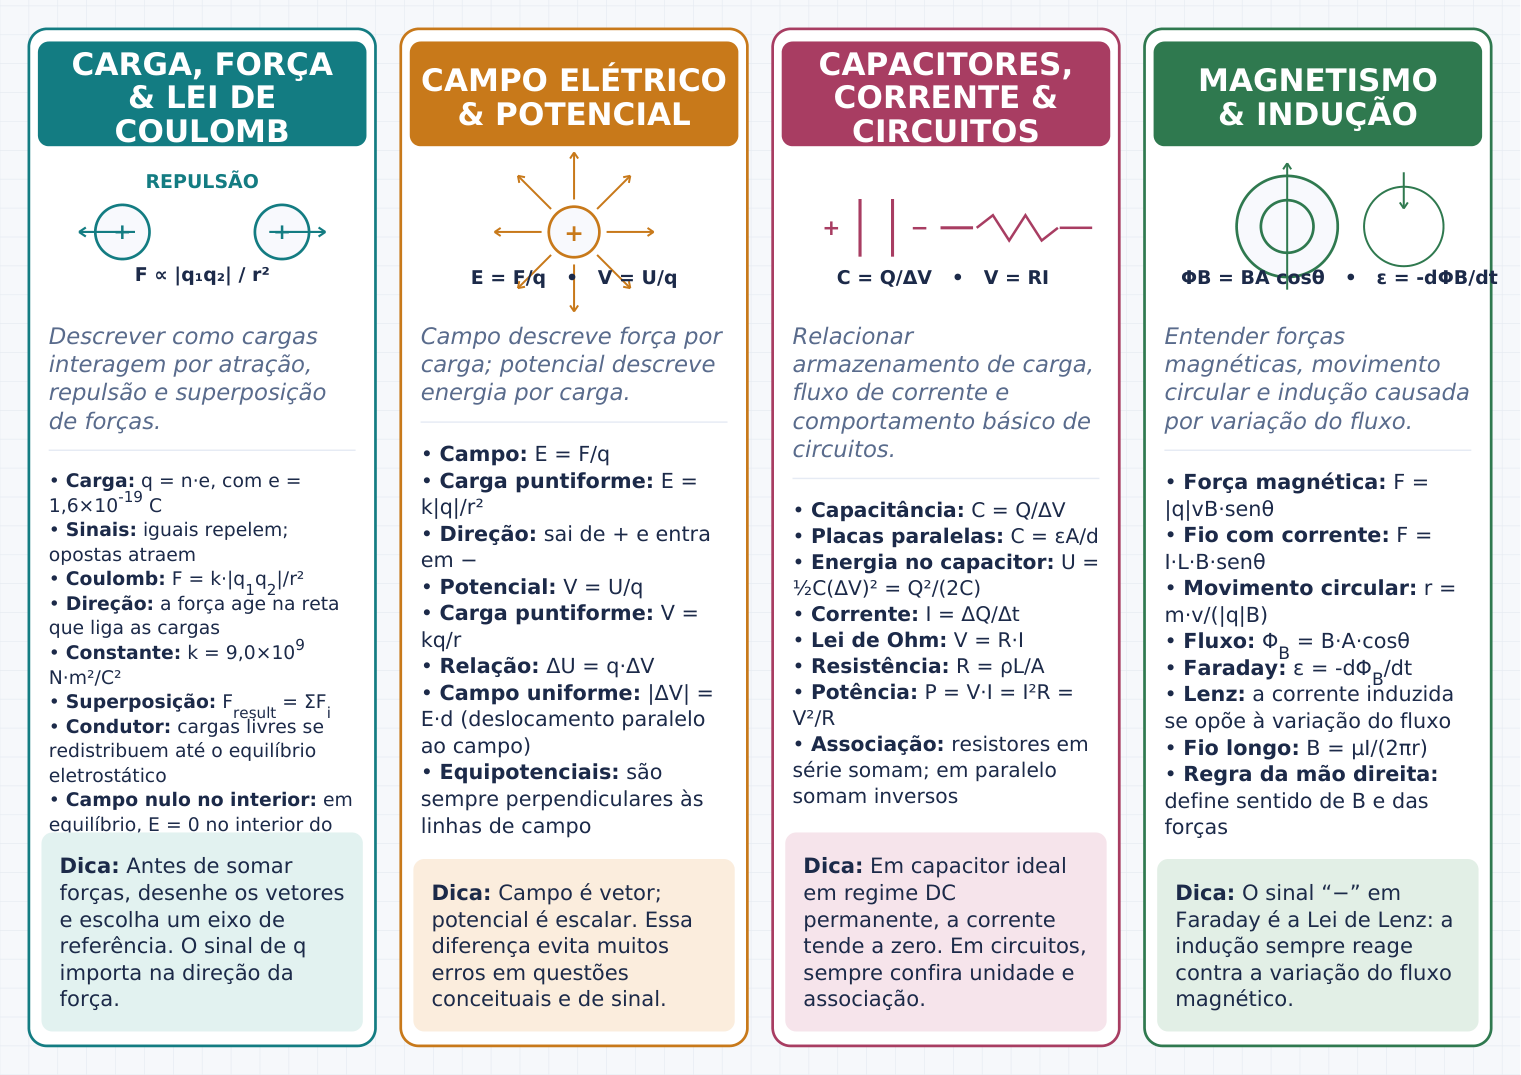

In [2]:
import pymupdf as fitz
from IPython.display import display, Image

doc = fitz.open(Path('Principios_Eletricidade_Magnetismo.pdf'))
print(f'Páginas: {len(doc)}')
for i, page in enumerate(doc, 1):
    pix = page.get_pixmap(dpi=130)
    display(Image(data=pix.tobytes('png')))


## 🎯 Exemplos práticos

Código executável que demonstra os conceitos da matéria com **saídas reais** (cálculos, simulações e gráficos).


1) LEI DE COULOMB: duas cargas de 1 uC separadas por 0,5 m
   F = 0.036 N (repulsiva, cargas iguais)

2) CAMPO ELETRICO de carga q = 2 nC a 1 m de distancia
   E = 18.0 N/C

3) POTENCIAL: V = k*q/r (mesma carga)
   V = 18.0 V

4) CIRCUITO RC: carga do capacitor, R=1 kOhm, C=100 uF, V=12 V
   tau = 100.0 ms | carga final = 1200.0 uC

5) FORCA DE LORENTZ: F = q*v*B (v perpendicular a B)
   F = 1.600e-13 N

6) LINHAS DE CAMPO de uma carga positiva (2D)


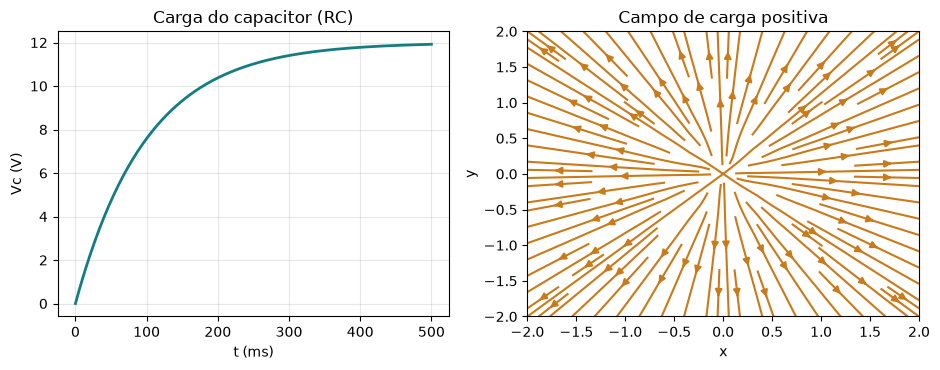


OK - eletricidade e magnetismo calculados numericamente.


In [3]:

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

k = 8.9875e9

print("=" * 60)
print("1) LEI DE COULOMB: duas cargas de 1 uC separadas por 0,5 m")
q1, q2, r = 1e-6, 1e-6, 0.5
F = k*q1*q2/r**2
print(f"   F = {F:.3f} N (repulsiva, cargas iguais)")

print("\n2) CAMPO ELETRICO de carga q = 2 nC a 1 m de distancia")
q, r2 = 2e-9, 1.0
E = k*q/r2**2
print(f"   E = {E:.1f} N/C")

print("\n3) POTENCIAL: V = k*q/r (mesma carga)")
print(f"   V = {k*q/r2:.1f} V")

print("\n4) CIRCUITO RC: carga do capacitor, R=1 kOhm, C=100 uF, V=12 V")
R, C, V = 1e3, 100e-6, 12.0
tau = R*C
t_charg = np.linspace(0, 5*tau, 300)
Q = C*V*(1 - np.exp(-t_charg/tau))
Vc = V*(1 - np.exp(-t_charg/tau))
print(f"   tau = {tau*1000:.1f} ms | carga final = {C*V*1e6:.1f} uC")

fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.8))
ax[0].plot(t_charg*1e3, Vc, color="#147D82", lw=2)
ax[0].set_title("Carga do capacitor (RC)"); ax[0].set_xlabel("t (ms)"); ax[0].set_ylabel("Vc (V)")
ax[0].grid(alpha=.3)

print("\n5) FORCA DE LORENTZ: F = q*v*B (v perpendicular a B)")
q, v, B = 1.6e-19, 2e6, 0.5
print(f"   F = {q*v*B:.3e} N")

print("\n6) LINHAS DE CAMPO de uma carga positiva (2D)")
x2 = np.linspace(-2, 2, 15); y2 = np.linspace(-2, 2, 15)
X, Y = np.meshgrid(x2, y2)
R2 = np.sqrt(X**2 + Y**2) + 1e-6
Ex = k*q1/X.shape[0]*0 + X/R2**3   # campo de carga q na origem (escala arbitraria)
Ey = Y/R2**3
ax[1].streamplot(X, Y, Ex, Ey, color="#C97A1A", density=1.2)
ax[1].set_title("Campo de carga positiva"); ax[1].set_xlabel("x"); ax[1].set_ylabel("y")
plt.tight_layout(); plt.show()
print("\nOK - eletricidade e magnetismo calculados numericamente.")


## 🚀 Como executar

1. Instale as dependências: `pip install -r requirements.txt`
2. Abra este notebook no Jupyter (`jupyter notebook`) ou VS Code.
3. Execute as células em ordem (`Run All`).

> 💡 O notebook foi **pré-executado**: as saídas já estão embutidas, mas você pode rodar novamente para reproduzir.
